### PREPROCESSING

In [1]:
# ================
# 1. PREPROCESSING
# ================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import re
import warnings
from catboost import CatBoostClassifier, Pool, EFstrType
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, PrecisionRecallDisplay, average_precision_score
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

# Ścieżki
data_path = ""
output_dir = os.path.join(data_path, "Wyniki_XAI_CatBoost")
os.makedirs(output_dir, exist_ok=True)

# Dane
train = pd.read_parquet(f"{data_path}/final_base_rf_train.parquet")
test  = pd.read_parquet(f"{data_path}/final_base_rf_test.parquet")

# Usunięcie target i postal_code
X_train = train.drop(columns=["default_flag", "postal_code"], errors="ignore")
y_train = train["default_flag"]
X_test  = test.drop(columns=["default_flag", "postal_code"], errors="ignore")
y_test  = test["default_flag"]

# Funkcja do konwersji YYYYMM -> Timestamp
def yyyymm_to_date(val):
    try:
        val = int(val)
        return pd.Timestamp(year=val // 100, month=val % 100, day=1)
    except Exception:
        return pd.NaT

# Inżynieria cech z dat + usunięcie kolumn Timestamp
for df in [X_train, X_test]:
    # first_payment_date
    if "first_payment_date" in df.columns:
        df["first_payment_date_dt"] = df["first_payment_date"].apply(yyyymm_to_date)
        df["first_payment_year"] = df["first_payment_date_dt"].dt.year
        df.drop(columns=["first_payment_date_dt"], inplace=True, errors="ignore")
    # maturity_date
    if "maturity_date" in df.columns:
        df["maturity_date_dt"] = df["maturity_date"].apply(yyyymm_to_date)
        df["maturity_year"] = df["maturity_date_dt"].dt.year
        df.drop(columns=["maturity_date_dt"], inplace=True, errors="ignore")

# Usunięcie surowych dat
X_train.drop(columns=["first_payment_date", "maturity_date"], inplace=True, errors="ignore")
X_test.drop(columns=["first_payment_date", "maturity_date"], inplace=True, errors="ignore")

# Number_of_borrowers jako liczba
for df in [X_train, X_test]:
    if "number_of_borrowers" in df.columns:
        df["number_of_borrowers"] = pd.to_numeric(df["number_of_borrowers"], errors="coerce")

# Zamiana ew. nieprawidłowych wartości w kolumnach numerycznych (np. 'Y','N','X','.' itp.) na NaN
invalid_values = ['Y', 'N', 'X', '.', 'U']
for df in [X_train, X_test]:
    for col in df.columns:
        if df[col].dtype != 'object':  # numeryczne / mieszane
            df[col] = pd.to_numeric(df[col], errors="ignore")  # nie popsuj poprawnych
            try:
                df[col] = df[col].replace(invalid_values, np.nan)
            except Exception:
                pass

# Lista cech kategorycznych
cat_features_all = [
    'first_time_homebuyer_flag', 'mi_percentage', 'occupancy_status', 'channel',
    'property_state', 'property_type', 'loan_purpose', 'original_loan_term',
    'super_conforming_flag', 'harp_indicator', 'program_indicator',
    'mi_cancellation_indicator', 'seller_name', 'servicer_name'
]
cat_features = [c for c in cat_features_all if c in X_train.columns]

# Kategorie muszą być stringami, a braki oznaczone jako "Missing"
for df in [X_train, X_test]:
    for col in cat_features:
        df[col] = df[col].astype(str).fillna("Missing")

print("Używane zmienne kategoryczne:", cat_features)

Używane zmienne kategoryczne: ['first_time_homebuyer_flag', 'mi_percentage', 'occupancy_status', 'channel', 'property_state', 'property_type', 'loan_purpose', 'original_loan_term', 'super_conforming_flag', 'harp_indicator', 'program_indicator', 'mi_cancellation_indicator', 'seller_name', 'servicer_name']


### TUNING 

In [2]:
# =========
# 2. TUNING
# =========
import json
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from catboost import CatBoostClassifier

# Parametry do przeszukiwania
param_dist = {
    "iterations": [800, 1200, 1600],
    "learning_rate": [0.02, 0.05, 0.08],
    "depth": [6, 8, 10],
    "l2_leaf_reg": [3, 5, 7, 9],
    "bagging_temperature": [0.25, 0.5, 0.75, 1.0]
}

base_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    bootstrap_type="Bayesian",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=200,
    allow_writing_files=False,
    thread_count=-1,
    early_stopping_rounds=50
)

# Próba do tuningu
TUNE_SAMPLE = 100_000
if len(X_train) > TUNE_SAMPLE:
    idx = np.random.RandomState(42).choice(X_train.index, size=TUNE_SAMPLE, replace=False)
    X_tune, y_tune = X_train.loc[idx], y_train.loc[idx]
else:
    X_tune, y_tune = X_train, y_train

print(f"Tuning CatBoost na {len(X_tune):,} rekordach...")

# -CV z printami
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Start tuningu...")

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=10,          # Liczba kombinacji do sprawdzenia
    cv=cv,
    scoring="roc_auc",
    verbose=10,        
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_tune, y_tune, cat_features=cat_features)


print("Najlepsze parametry (CV):", random_search.best_params_)

# Zapis najlepszych parametrów do pliku
best_params_path = os.path.join(output_dir, "best_params_cat.json")
with open(best_params_path, "w") as f:
    json.dump(random_search.best_params_, f)

print(f"Zapisano najlepsze parametry do: {best_params_path}")


Tuning CatBoost na 100,000 rekordach...
Start tuningu...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
0:	total: 263ms	remaining: 6m 59s
200:	total: 23.3s	remaining: 2m 42s
400:	total: 45.3s	remaining: 2m 15s
600:	total: 1m 7s	remaining: 1m 52s
800:	total: 1m 32s	remaining: 1m 32s
1000:	total: 1m 58s	remaining: 1m 10s
1200:	total: 2m 23s	remaining: 47.7s
1400:	total: 2m 49s	remaining: 24.1s
1599:	total: 3m 14s	remaining: 0us
Najlepsze parametry (CV): {'learning_rate': 0.02, 'l2_leaf_reg': 7, 'iterations': 1600, 'depth': 6, 'bagging_temperature': 0.25}
Zapisano najlepsze parametry do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XAI_CatBoost\best_params_cat.json


### FINALNY MODEL

In [2]:
# ===========================
# 3. FINALNY MODEL – CATBOOST
# ===========================
import json
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool, EFstrType
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Wczytanie parametrów z tuningu
best_params_path = os.path.join(output_dir, "best_params_cat.json")
with open(best_params_path, "r") as f:
    best_params = json.load(f)

# Wybór próby stratyfikowanej
REFIT_SAMPLE = 5_000_000
if len(X_train) > REFIT_SAMPLE:
    X_refit, _, y_refit, _ = train_test_split(
        X_train, y_train,
        train_size=REFIT_SAMPLE,
        stratify=y_train,
        random_state=42
    )
else:
    X_refit, y_refit = X_train, y_train

print(f"Refit CatBoost na {len(X_refit):,} rekordach...")

# Finalny model
clf_best = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    bootstrap_type="Bayesian",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=200,
    allow_writing_files=False,
    thread_count=-1
)

clf_best.fit(X_refit, y_refit, cat_features=cat_features)

# =========
# PREDYKCJE
# =========
y_pred  = clf_best.predict(X_test)
y_proba = clf_best.predict_proba(X_test)[:, 1]

X_test["y_proba"] = y_proba
X_test["y_pred"]  = y_pred
X_test["y_true"]  = y_test.values

print("AUC (test):", roc_auc_score(y_test, y_proba))

# Zapis modelu
model_path = os.path.join(output_dir, "catboost_model_final.pkl")
joblib.dump(clf_best, model_path)
print(f"Model zapisany do: {model_path}")

# Zapis testu z predykcjami
test_with_preds_path = os.path.join(output_dir, "catboost_test_with_preds.parquet")
X_test.to_parquet(test_with_preds_path, index=False)
print(f"Test z predykcjami zapisany do: {test_with_preds_path}")

# Zapis feature_names
feature_names = X_train.columns.tolist()
features_path = os.path.join(output_dir, "catboost_feature_names.npy")
np.save(features_path, np.array(feature_names))
print(f"Feature names zapisane do: {features_path}")

# =======================
# SHAP – liczenie i zapis
# =======================
shap_sample_n = min(500_000, len(X_test))
X_shap = X_test.sample(n=shap_sample_n, random_state=42)
pool_shap = Pool(X_shap, cat_features=[c for c in cat_features if c in X_shap.columns])

shap_raw = clf_best.get_feature_importance(data=pool_shap, type=EFstrType.ShapValues)
shap_values = shap_raw[:, :-1]
base_values = shap_raw[:, -1]

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_shap,
    feature_names=X_shap.columns
)

# Zapis shap_values i base_values
np.save(os.path.join(output_dir, "shap_values.npy"), shap_values)
np.save(os.path.join(output_dir, "shap_base_values.npy"), base_values)

# -Zapis próby cech
X_shap.to_parquet(os.path.join(output_dir, "shap_sample.parquet"))

# Ranking globalny
importances = np.abs(shap_values).mean(axis=0)
importances_series = pd.Series(importances, index=X_shap.columns).sort_values(ascending=False)
importances_series.to_csv(os.path.join(output_dir, "shap_importances.csv"))

# Listy top5, TOP_CONT, TOP_CAT
top5 = importances_series.head(5).index.tolist()

def _is_dummy01(s: pd.Series) -> bool:
    u = pd.Series(pd.to_numeric(s, errors="coerce").dropna().unique())
    return (len(u) > 0) and u.isin([0, 1]).all()

_EXCLUDE_NAME_TOKENS = ["msa","zip","postal","code","id","year","month","date","day","days_since","number_of_borrowers"]
_EXCLUDE_EXACT = {"first_payment_year"}

def _is_name_excluded(name: str) -> bool:
    n = str(name).lower()
    if n in _EXCLUDE_EXACT: return True
    return any(tok in n for tok in _EXCLUDE_NAME_TOKENS)

SAFE_CAT_FEATURES = [c for c in X_shap.columns if not _is_name_excluded(c) and _is_dummy01(X_shap[c])]
SAFE_CONT_FEATURES = [
    c for c in X_shap.columns
    if not _is_name_excluded(c)
    and pd.api.types.is_numeric_dtype(X_shap[c])
    and not _is_dummy01(X_shap[c])
    and X_shap[c].nunique(dropna=True) >= 3
]

TOP_ALL  = [c for c in top5 if c in X_shap.columns]
TOP_CONT = [c for c in TOP_ALL if c in SAFE_CONT_FEATURES]
TOP_CAT  = [c for c in TOP_ALL if c in SAFE_CAT_FEATURES]

# Zapis list
pd.Series(top5).to_csv(os.path.join(output_dir, "shap_top5.csv"), index=False)
pd.Series(TOP_CONT).to_csv(os.path.join(output_dir, "shap_top_cont.csv"), index=False)
pd.Series(TOP_CAT).to_csv(os.path.join(output_dir, "shap_top_cat.csv"), index=False)

print("SHAP + listy cech zapisane.")

Refit CatBoost na 5,000,000 rekordach...
0:	total: 4.04s	remaining: 1h 47m 43s
200:	total: 12m 2s	remaining: 1h 23m 51s
400:	total: 24m 18s	remaining: 1h 12m 39s
600:	total: 36m 42s	remaining: 1h 1m
800:	total: 48m 41s	remaining: 48m 33s
1000:	total: 1h 1m 3s	remaining: 36m 32s
1200:	total: 1h 13m 28s	remaining: 24m 24s
1400:	total: 1h 25m 52s	remaining: 12m 11s
1599:	total: 1h 38m 11s	remaining: 0us
AUC (test): 0.859859077880227
Model zapisany do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XAI_CatBoost\catboost_model_final.pkl
Test z predykcjami zapisany do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XAI_CatBoost\catboost_test_with_preds.parquet
Feature names zapisane do: C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza\Wyniki_XAI_CatBoost\catboost_feature_names.npy
SHAP + listy cech zapisane.


### ANALIZY

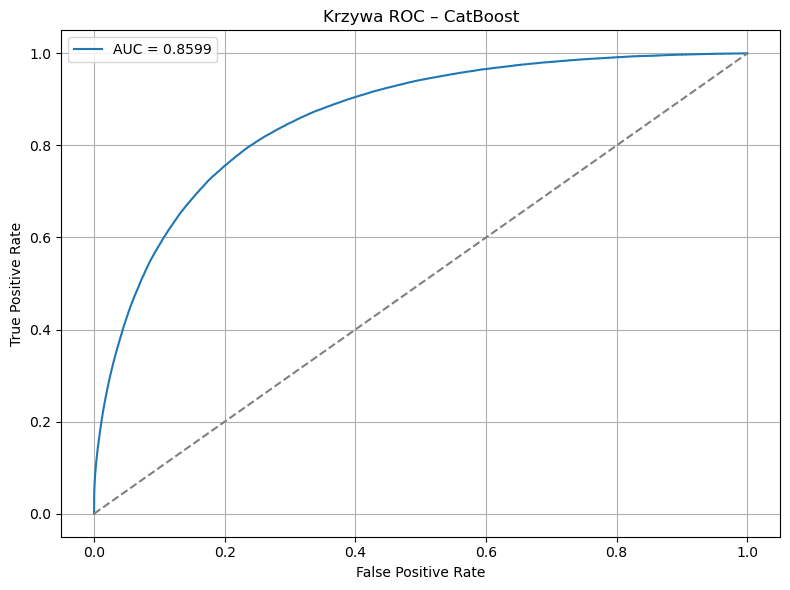

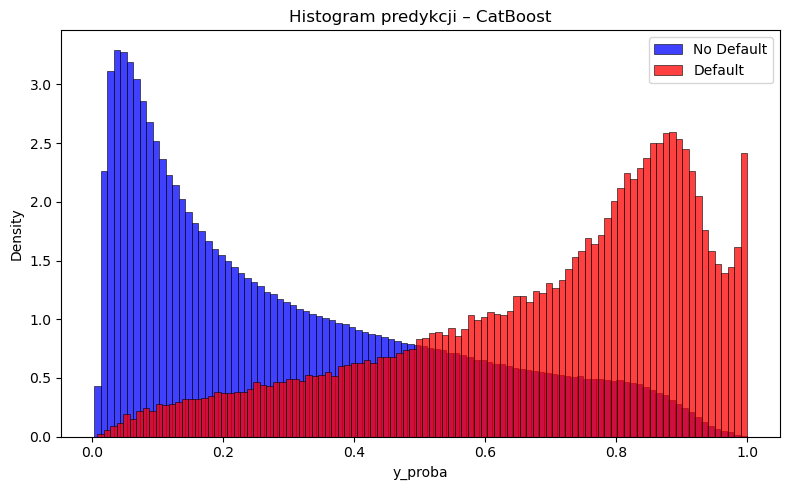

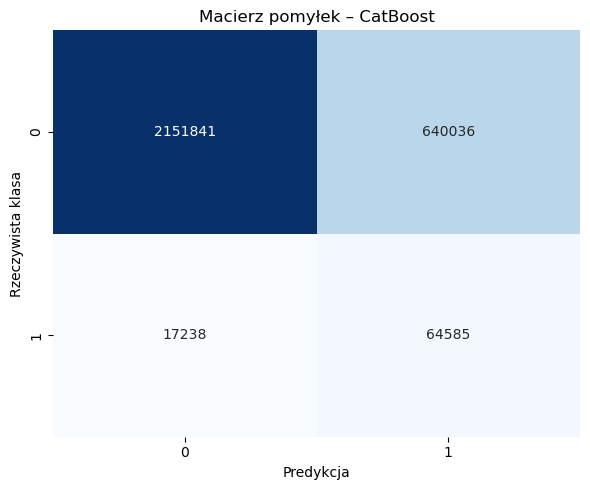

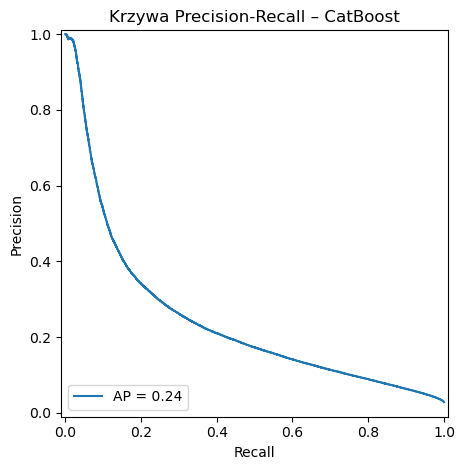

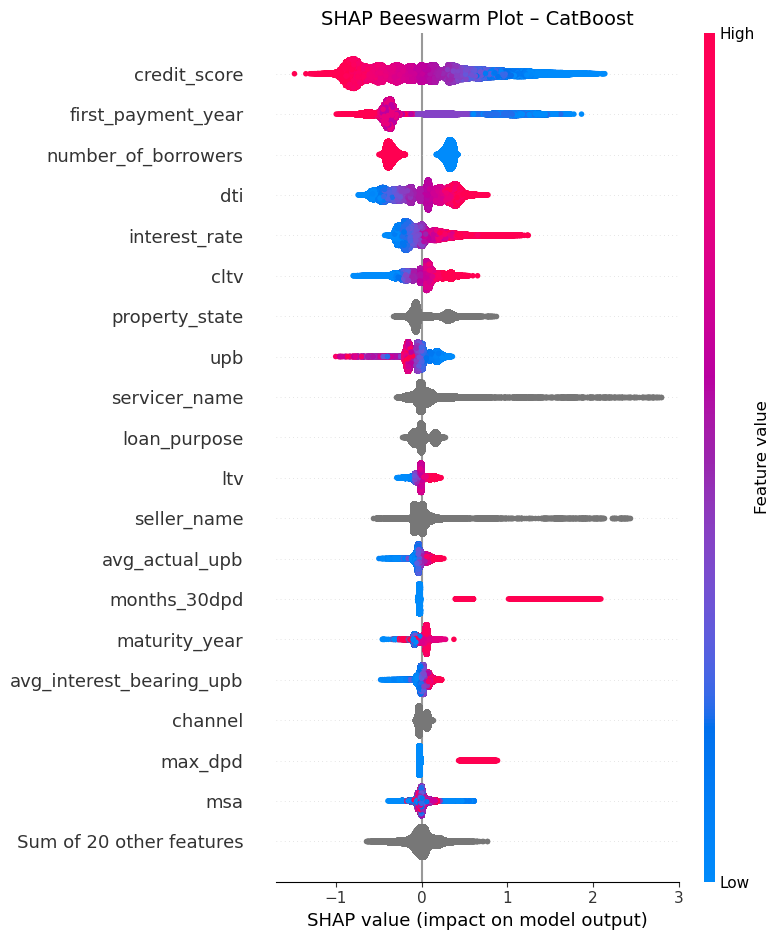

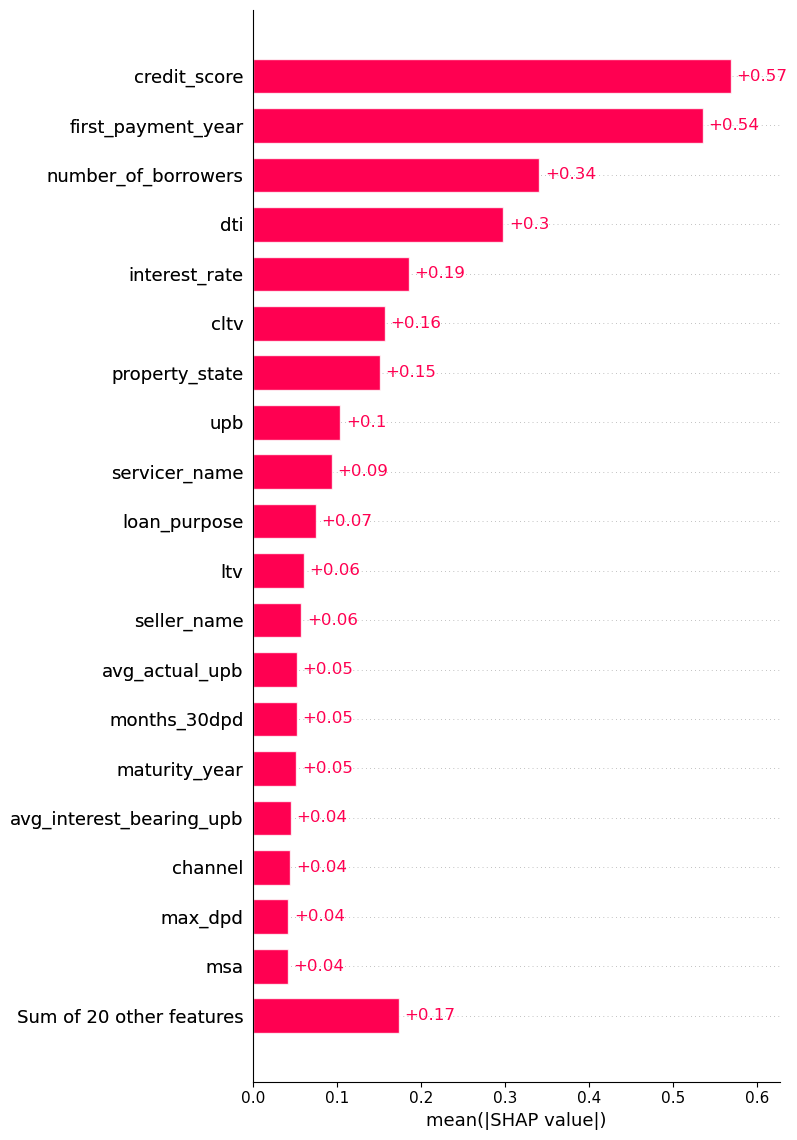

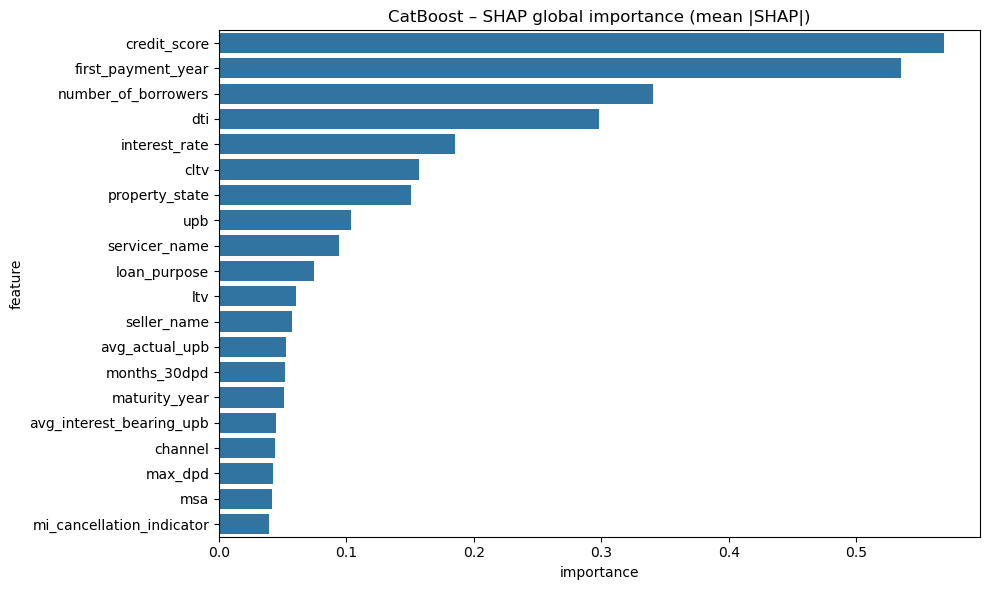

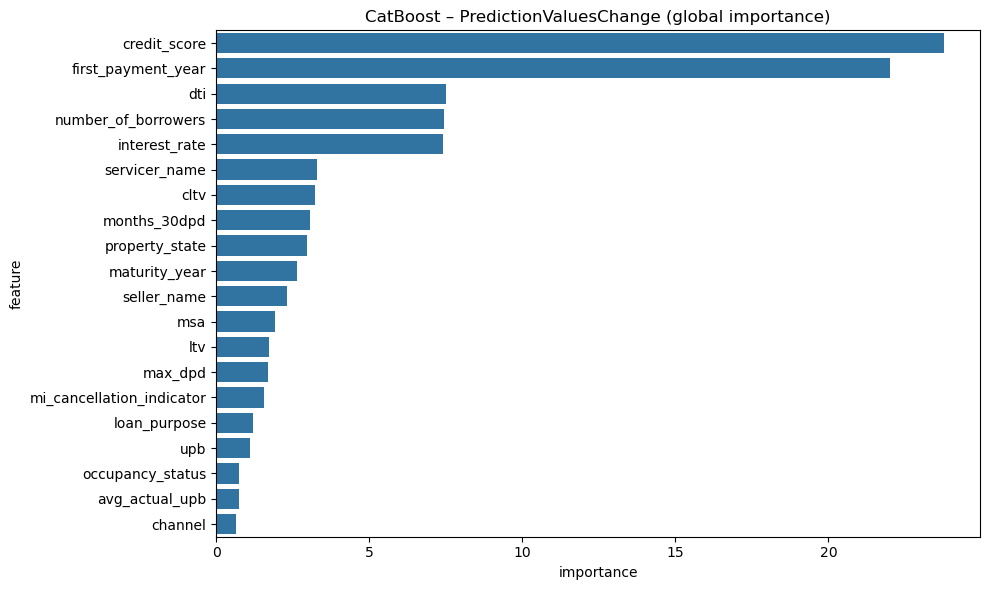

<Figure size 640x480 with 0 Axes>

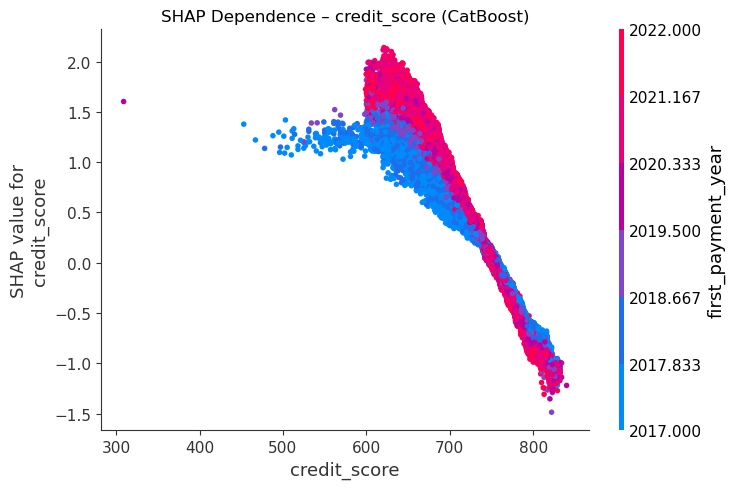

<Figure size 640x480 with 0 Axes>

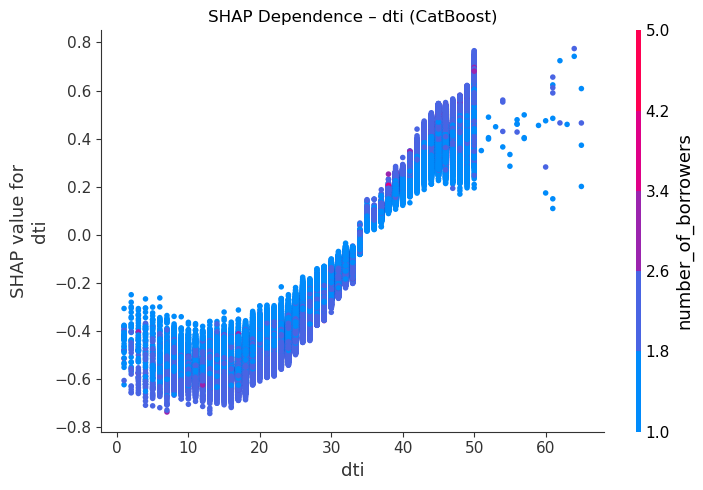

<Figure size 640x480 with 0 Axes>

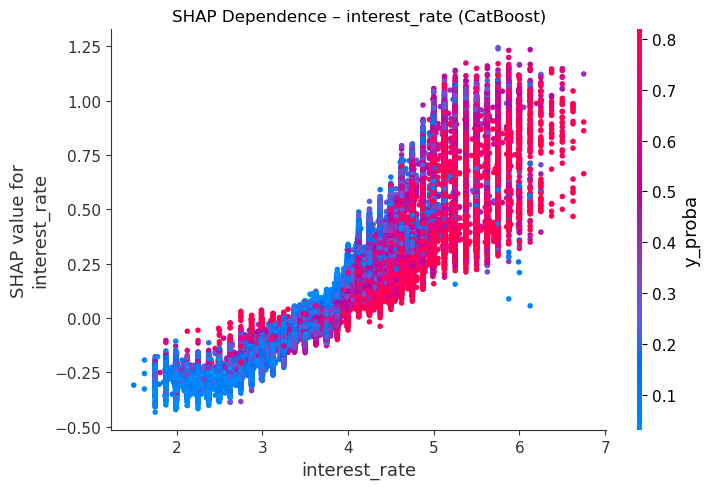

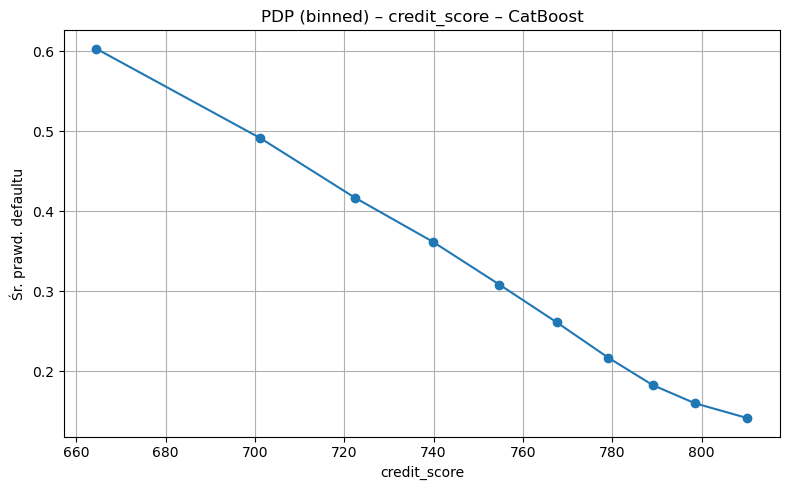

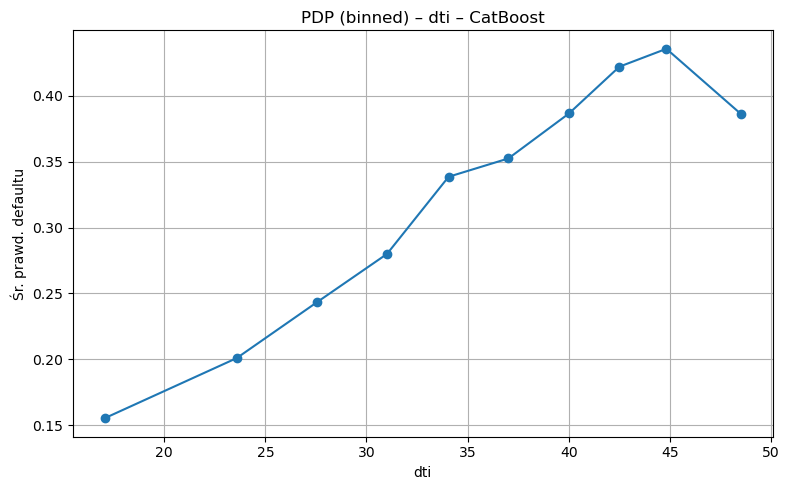

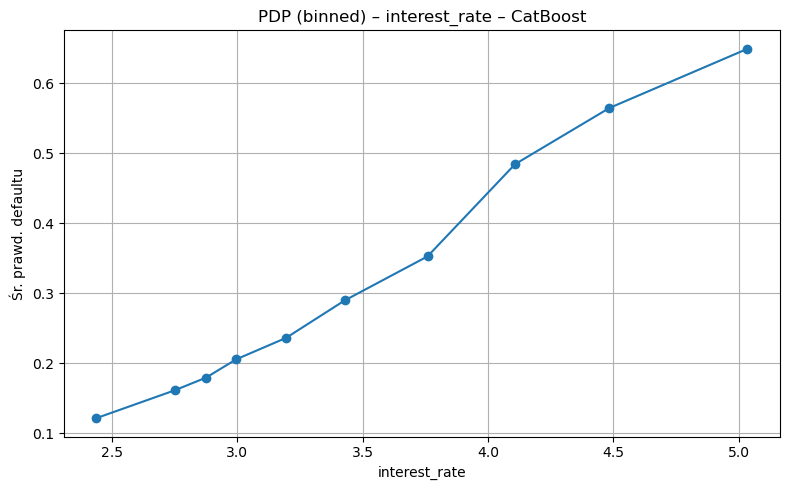

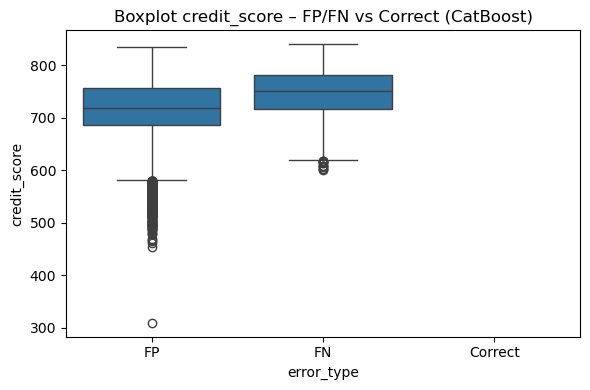

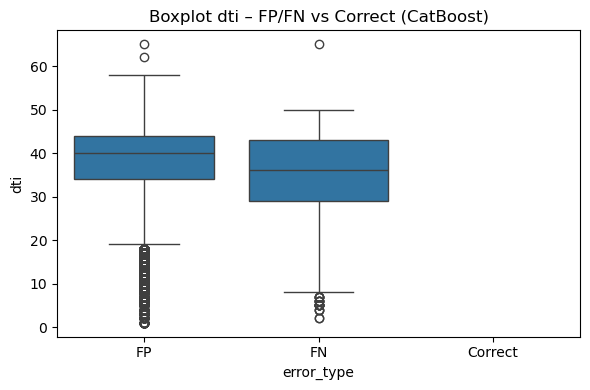

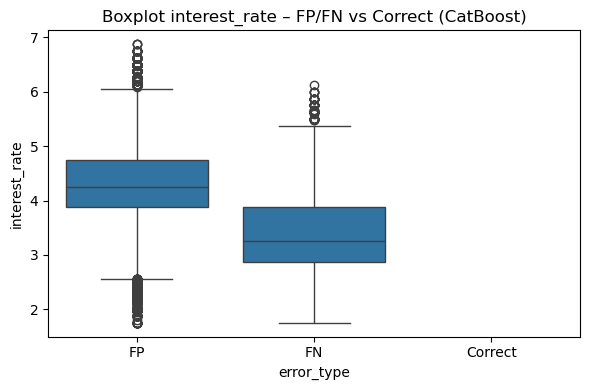

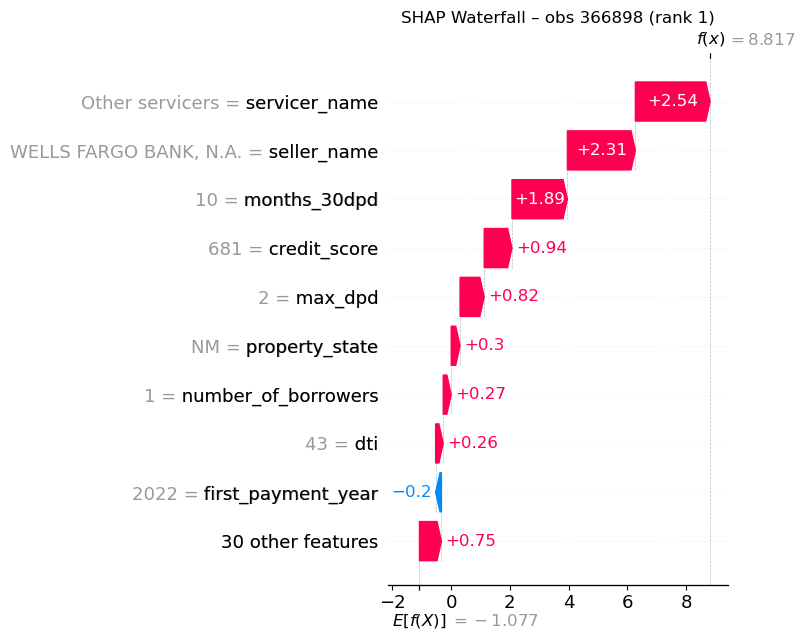

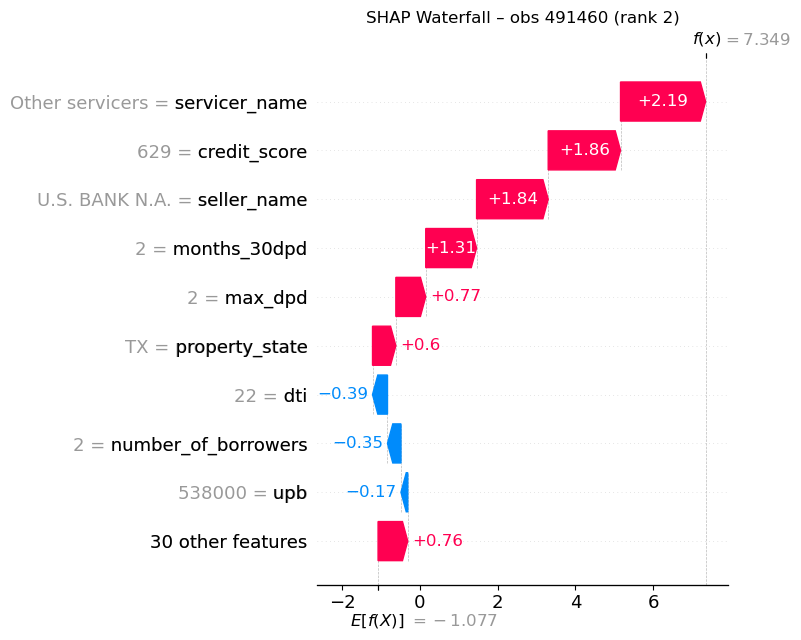

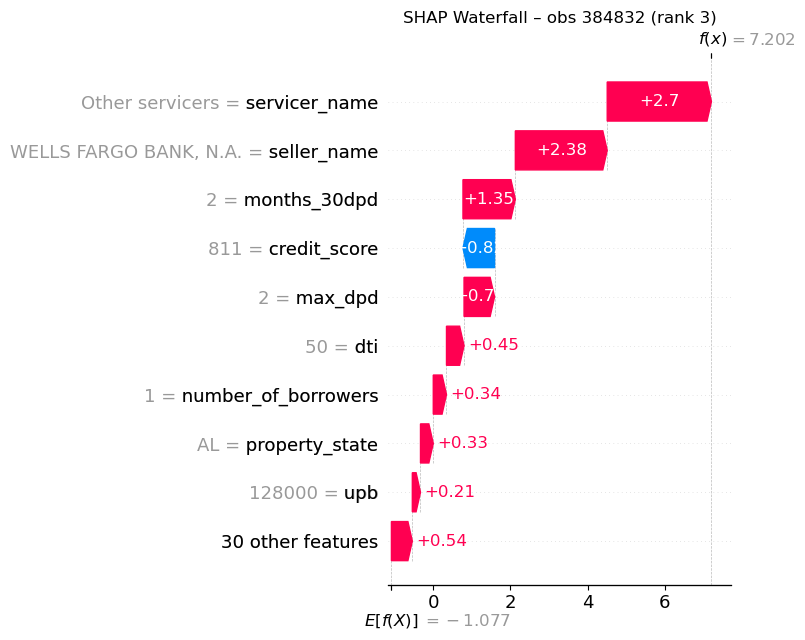

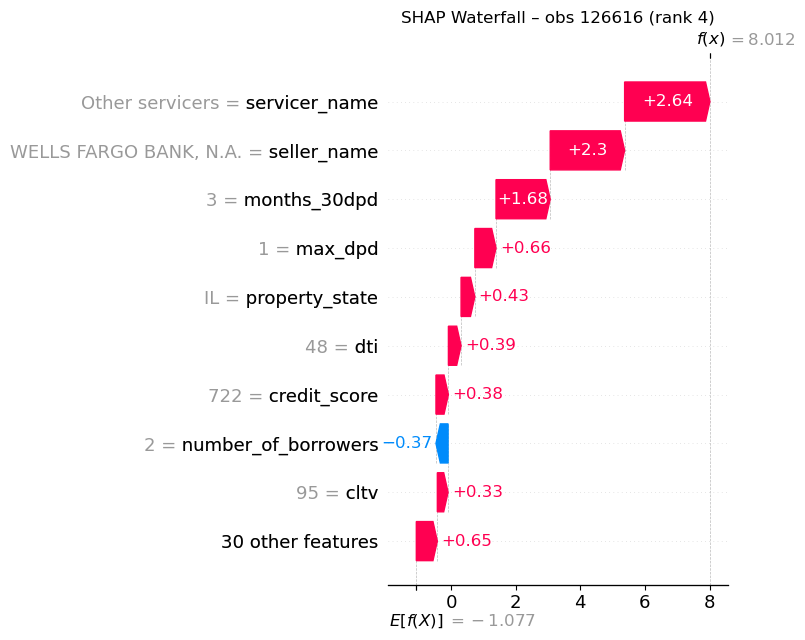

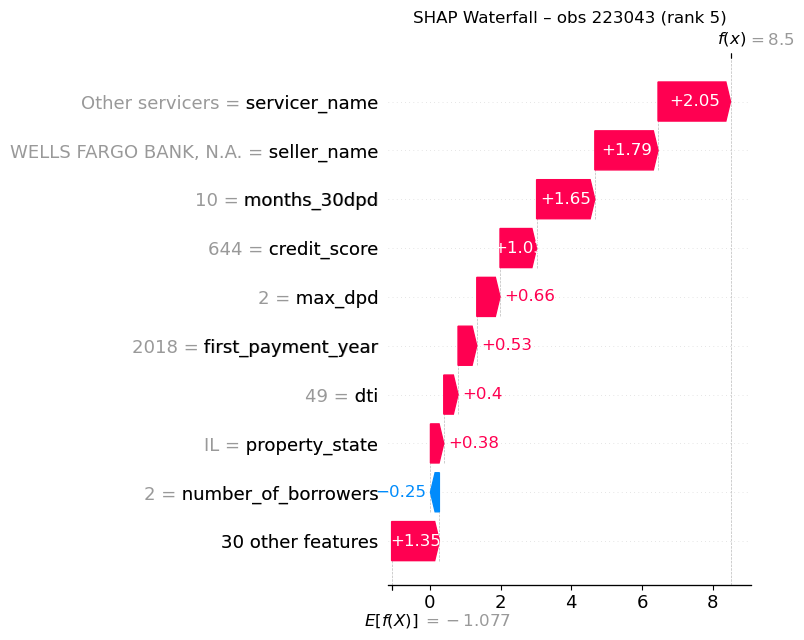

AUC per year: stratyfikacja po TOP5 cechach (kwantyle) – CatBoost
AUC per year: stratyfikacja po TOP_CONT (kwantyle) – CatBoost


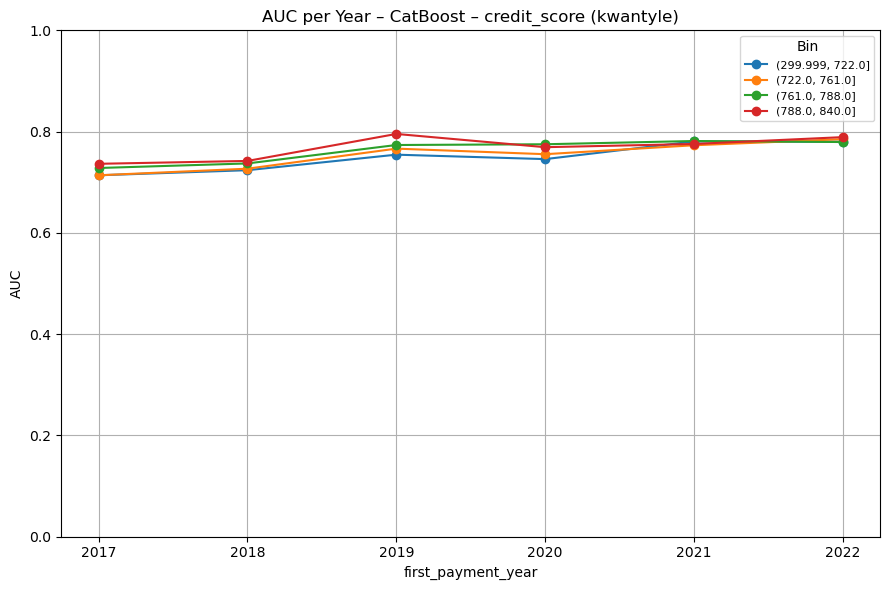

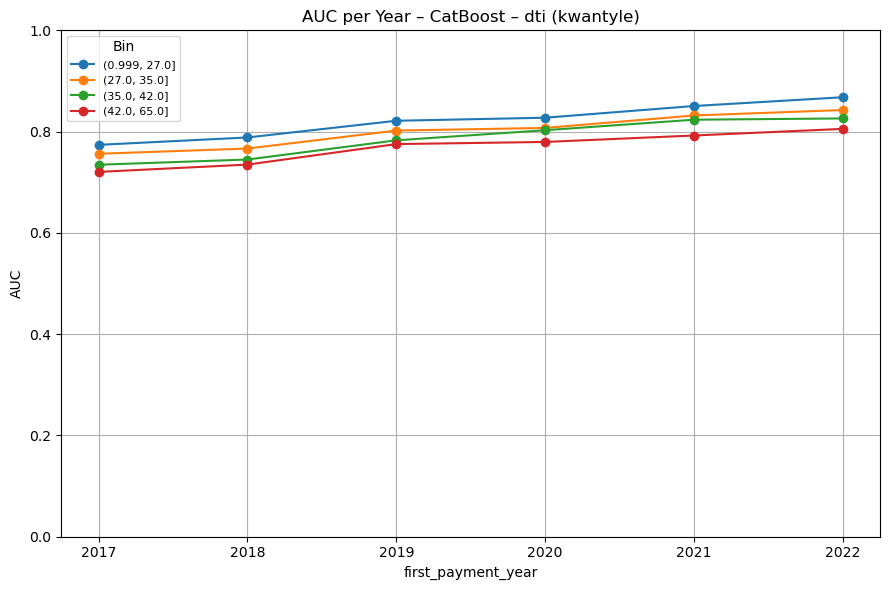

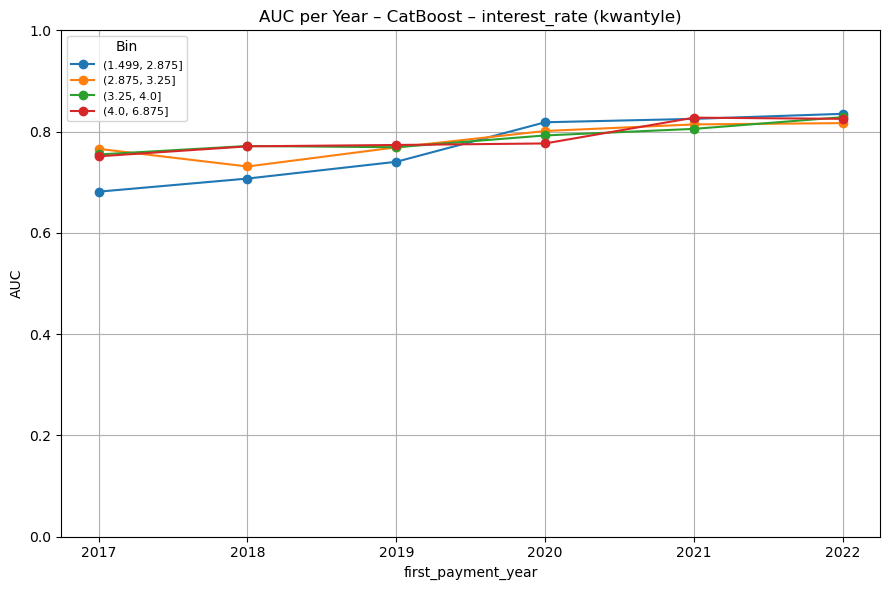

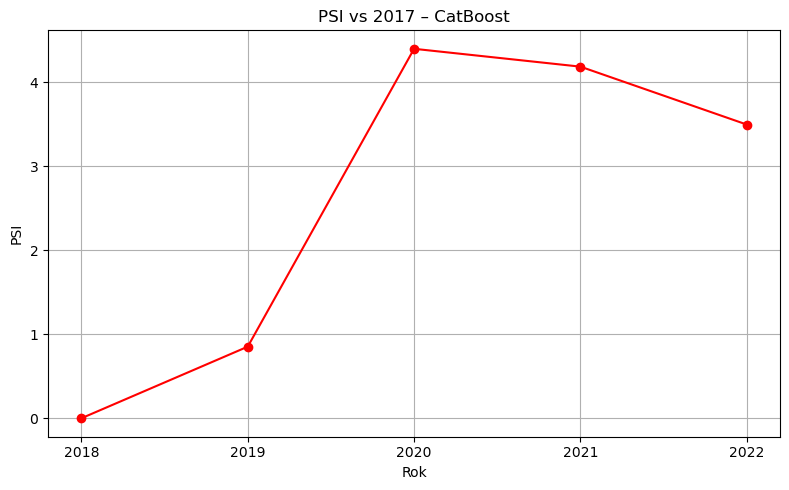

CSI (Top5): bazowy rok vs bieżące dane – CatBoost
Obliczanie CSI względem roku bazowego: 2017


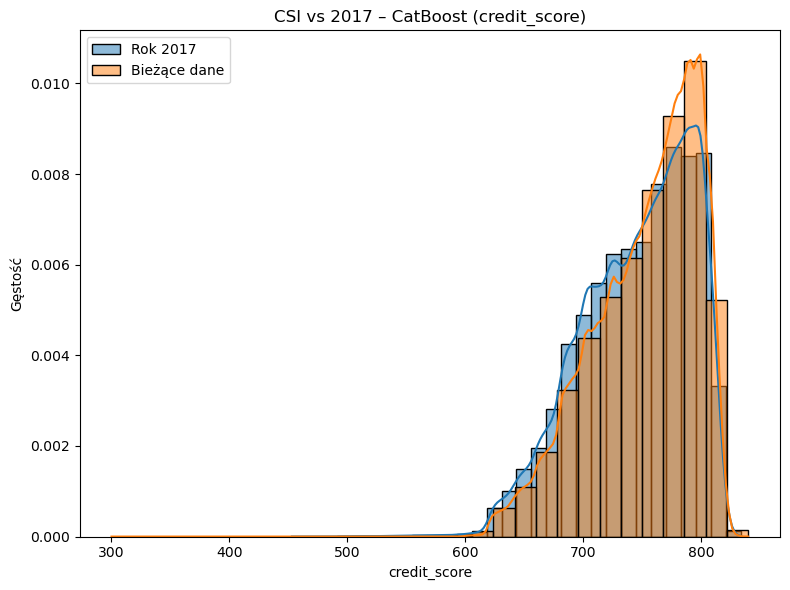

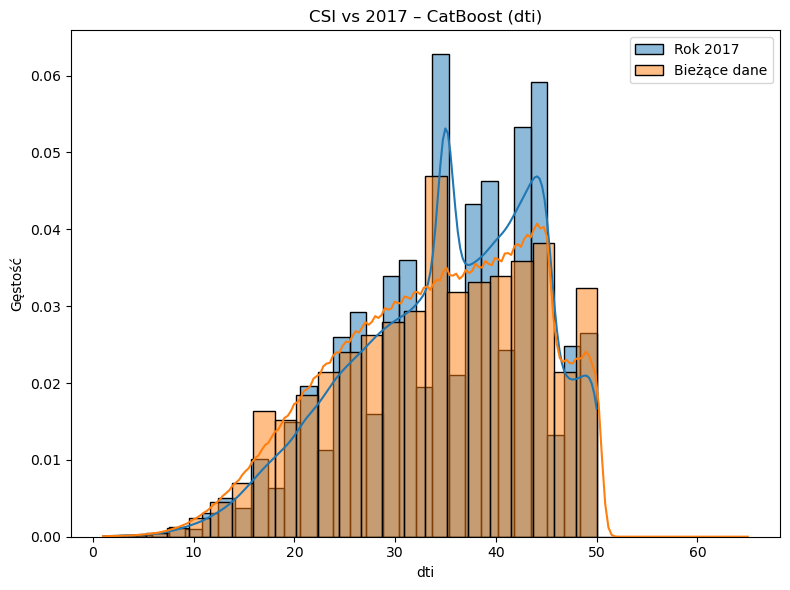

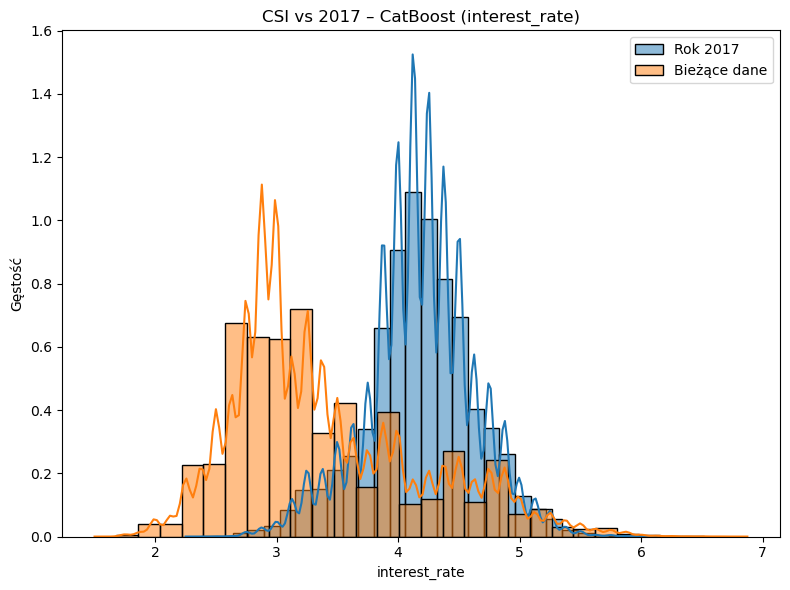

Perturbacja – TOP_CONT (CatBoost)
Perturbacja – cechy: ['credit_score', 'dti', 'interest_rate']


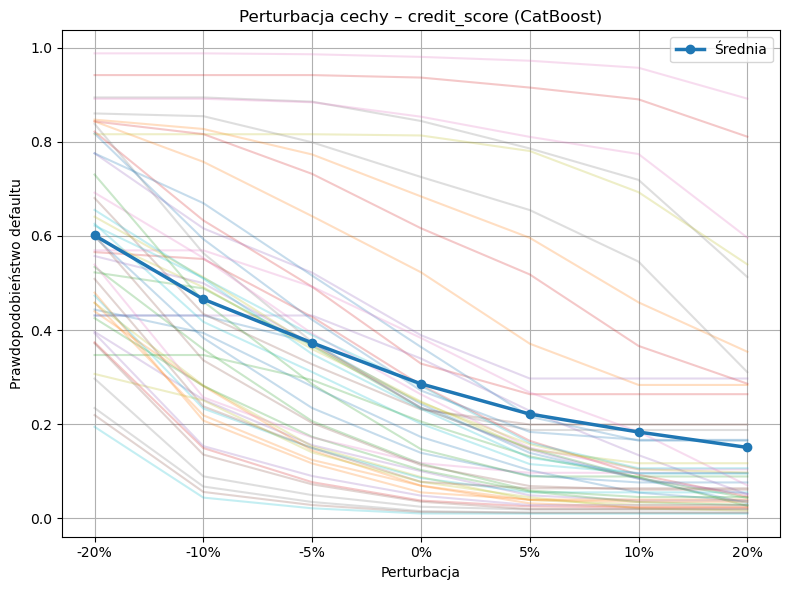

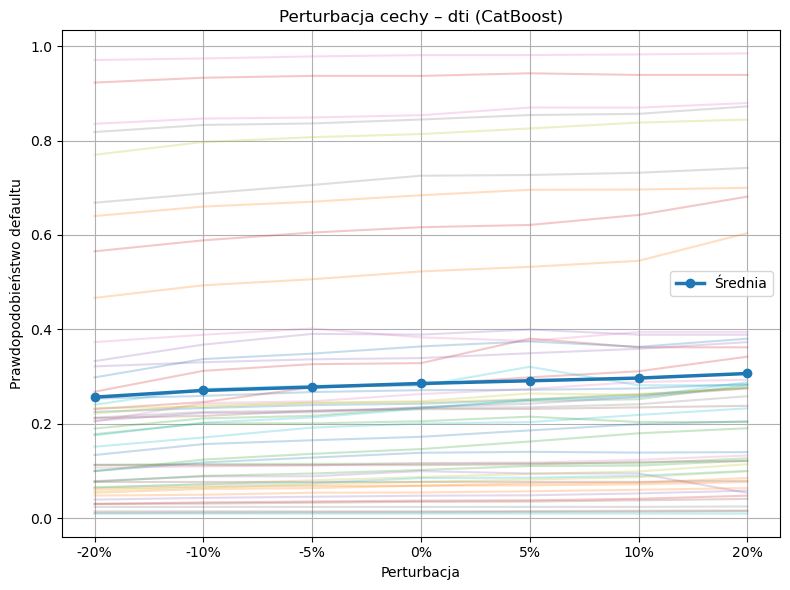

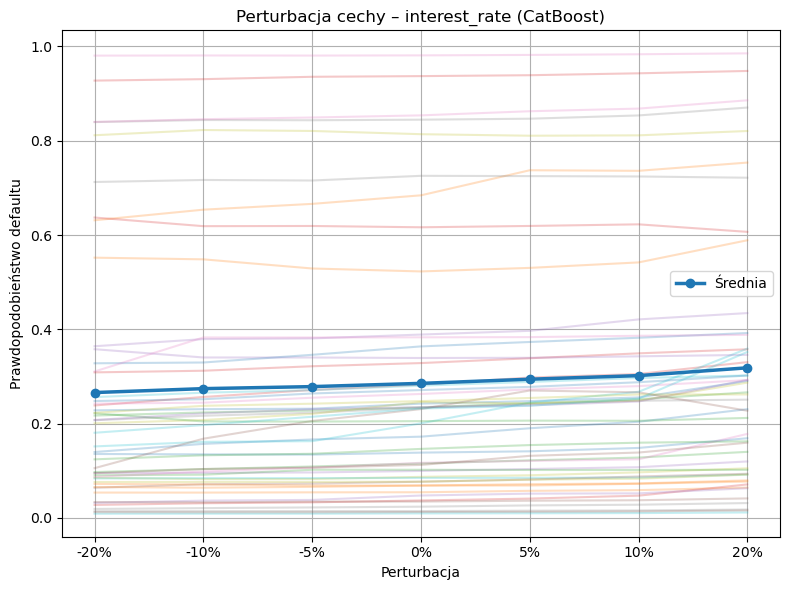

Zapisano: catboost_feature_perturbation_summary.csv


In [6]:
#===========
# 4. ANALIZY
#===========

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shap
import joblib
import os
import re
import warnings
from catboost import CatBoostClassifier, Pool, EFstrType
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, PrecisionRecallDisplay, average_precision_score
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

def cleanup(*objs):
    """Usuwa wskazane obiekty i czyści RAM"""
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    plt.close("all")
    gc.collect()

def _safe_fname(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-._" else "_" for ch in str(s))

warnings.filterwarnings("ignore")

# Ścieżki
data_path = ""
output_dir = os.path.join(data_path, "Wyniki_XAI_CatBoost")
os.makedirs(output_dir, exist_ok=True)

model = joblib.load(os.path.join(output_dir, "catboost_model_final.pkl"))

X_test = pd.read_parquet(os.path.join(output_dir, "catboost_test_with_preds.parquet"))
y_test = X_test["y_true"]
y_proba = X_test["y_proba"]
y_pred  = X_test["y_pred"]

shap_values = np.load(os.path.join(output_dir, "shap_values.npy"))
base_values = np.load(os.path.join(output_dir, "shap_base_values.npy"))
X_shap = pd.read_parquet(os.path.join(output_dir, "shap_sample.parquet"))

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_shap,
    feature_names=X_shap.columns
)

top5      = pd.read_csv(os.path.join(output_dir, "shap_top5.csv")).squeeze().tolist()
TOP_CONT  = pd.read_csv(os.path.join(output_dir, "shap_top_cont.csv")).squeeze().tolist()
TOP_CAT   = pd.read_csv(os.path.join(output_dir, "shap_top_cat.csv")).squeeze().tolist()

#====
# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Krzywa ROC – CatBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/roc_curve_catboost.png")
plt.show()
plt.close()

#====================
# Histogram predykcji
plt.figure(figsize=(8, 5))
sns.histplot(y_proba[y_test == 0], color="blue", label="No Default", stat="density", bins=100)
sns.histplot(y_proba[y_test == 1], color="red",  label="Default",   stat="density", bins=100)
plt.legend()
plt.title("Histogram predykcji – CatBoost")
plt.tight_layout()
plt.savefig(f"{output_dir}/prediction_hist_catboost.png")
plt.show()
plt.close()

#=================
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Macierz pomyłek – CatBoost")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrix_catboost.png")
plt.show()
plt.close()

#=================
# Precision–Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap)
disp.plot()
plt.title("Krzywa Precision-Recall – CatBoost")
plt.tight_layout()
plt.savefig(f"{output_dir}/precision_recall_catboost.png")
plt.show()
plt.close()

#=======================
# Permutation Importance 
from sklearn.inspection import permutation_importance

pi_n = min(10000, len(X_test))
X_pi = X_test.sample(n=pi_n, random_state=42)
y_pi = y_test.loc[X_pi.index]

pi = permutation_importance(
    model, X_pi, y_pi,
    n_repeats=2,  # szybkie
    scoring="roc_auc",
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_pi.columns,
    "importance_mean": pi.importances_mean,
    "importance_std": pi.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.to_csv(f"{output_dir}/permutation_importance_catboost.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df.head(10), x="importance_mean", y="feature")
plt.title("Permutation Importance (top 10) – CatBoost")
plt.xlabel("Mean decrease in AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{output_dir}/permutation_importance_top10_catboost.png")
plt.close()

#==============================
# # SHAP (natywna miara CatBoost)

# Summary – dot
plt.figure()
shap.plots.beeswarm(shap_exp, max_display=20, show=False)
plt.title("SHAP Beeswarm Plot – CatBoost", fontsize=14)
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_summary_dot_catboost.png")
plt.show()
plt.close()

# Summary – bar
plt.figure()
shap.plots.bar(shap_exp, max_display=20, show=False)
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_summary_bar_catboost.png")
plt.show()
plt.close()

# SHAP importance (mean |SHAP|)
shap_global = (np.abs(shap_exp.values).mean(axis=0))
shap_imp_df = pd.DataFrame({
    "feature": X_shap.columns,
    "importance": shap_global
}).sort_values("importance", ascending=False)
shap_imp_df.to_csv(f"{output_dir}/catboost_importance_shap_meanabs.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_imp_df.head(20), x="importance", y="feature")
plt.title("CatBoost – SHAP global importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(f"{output_dir}/catboost_importance_shap_meanabs_top20.png")
plt.show(); plt.close()

# Natywne miary CatBoost: PredictionValuesChange (global feature importance)
from catboost import EFstrType

pvc_vals = model.get_feature_importance(type=EFstrType.PredictionValuesChange)
feat_names = list(X_train.columns)

if len(pvc_vals) != len(feat_names):
    try:
        feat_names = list(model.feature_names_)
    except Exception:
        pass

pvc_df = (
    pd.DataFrame({"feature": feat_names, "importance": pvc_vals})
    .sort_values("importance", ascending=False)
)

# Zapis rankingu + wykres Top-20
pvc_df.to_csv(f"{output_dir}/catboost_importance_prediction_values_change.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=pvc_df.head(20), x="importance", y="feature")
plt.title("CatBoost – PredictionValuesChange (global importance)")
plt.tight_layout()
plt.savefig(f"{output_dir}/catboost_importance_prediction_values_change_top20.png")
plt.show(); plt.close()

#================
# SHAP Dependence 
for feature in TOP_CONT:
    try:
        if feature not in X_shap.columns:
            continue
        if pd.to_numeric(X_shap[feature], errors="coerce").nunique(dropna=True) < 3:
            print(f"Pominięcie {feature} – za mało unikalnych wartości.")
            continue

        plt.figure()
        shap.dependence_plot(
            feature,           # nazwa cechy
            shap_values,       # ndarray: [n_obs, n_feat]
            X_shap,            # DataFrame z tymi samymi kolumnami
            interaction_index="auto",
            show=False
        )
        plt.title(f"SHAP Dependence – {feature} (CatBoost)")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"shap_dependence_{_safe_fname(feature)}_catboost.png"), dpi=150)
        plt.show(); plt.close()
    except Exception as e:
        print(f"Dependence plot – błąd dla {feature}: {e}")

#====================
# PDP (binned) – CONT
for feature in TOP_CONT:
    try:
        if feature not in X_test.columns:
            continue
        s = pd.to_numeric(X_test[feature], errors="coerce")
        if s.dropna().nunique() < 3:
            print(f"PDP: pominięcie {feature} – za mało unikalnych wartości.")
            continue
        df_tmp = pd.DataFrame({feature: s, "pred_proba": y_proba}).dropna()
        try:
            df_tmp["bin"] = pd.qcut(df_tmp[feature], q=10, duplicates="drop")
        except Exception:
            print(f"PDP: pominięcie {feature} – qcut nieudany.")
            continue
        grouped = (df_tmp.groupby("bin", observed=False)
                          .agg(x=(feature, "mean"), y=("pred_proba", "mean"))
                          .reset_index(drop=True))
        plt.figure(figsize=(8,5))
        plt.plot(grouped["x"], grouped["y"], marker="o")
        plt.title(f"PDP (binned) – {feature} – CatBoost")
        plt.xlabel(feature); plt.ylabel("Śr. prawd. defaultu")
        plt.grid(True); plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"pdp_binned_{_safe_fname(feature)}_catboost.png"), dpi=150)
        plt.show(); plt.close()
    except Exception as e:
        print(f"PDP (cont) – błąd dla {feature}: {e}")

#======================
# PDP (kategorie) – CAT
MAX_LEVELS = 10
for feature in TOP_CAT:
    try:
        if feature not in X_test.columns:
            continue
        dfc = pd.DataFrame({feature: X_test[feature].astype(str), "pred_proba": y_proba}).dropna()
        # top K najczęstszych kategorii
        topK = dfc[feature].value_counts().head(MAX_LEVELS).index
        dfc = dfc[dfc[feature].isin(topK)]
        if dfc.empty or dfc[feature].nunique() < 2:
            continue
        grouped = dfc.groupby(feature)["pred_proba"].mean().sort_values()
        ax = grouped.plot(kind="bar", figsize=(7, 4))
        ax.set_title(f"PDP (kategorie) – {feature} – CatBoost")
        ax.set_xlabel(feature); ax.set_ylabel("Śr. prawd. defaultu")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"pdp_cat_{_safe_fname(feature)}_catboost.png"), dpi=150)
        plt.show(); plt.close()
    except Exception as e:
        print(f"PDP (cat) – błąd dla {feature}: {e}")

#================
# FP/FN + eksport
error_df = X_test.copy()
error_df["y_true"]  = y_test.values
error_df["y_pred"]  = y_pred
error_df["y_proba"] = y_proba
error_df["error_type"] = np.select(
    [(error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
     (error_df["y_true"] == 1) & (error_df["y_pred"] == 0)],
    ["FP", "FN"], default="Correct"
)
error_df[error_df["error_type"] != "Correct"].to_csv(
    f"{output_dir}/catboost_prediction_errors_fp_fn.csv", index=False
)

#==============================
# Boxplot FP vs FN dla top cech
error_df = X_test.copy()
error_df["y_true"]  = y_test.values
error_df["y_pred"]  = y_pred
error_df["y_proba"] = y_proba
error_df["error_type"] = np.select(
    [(error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
     (error_df["y_true"] == 1) & (error_df["y_pred"] == 0)],
    ["FP", "FN"], default="Correct"
)

err_subset = error_df[error_df["error_type"].isin(["FP", "FN"])].copy()
for feat in TOP_CONT:
    if feat in err_subset.columns and pd.api.types.is_numeric_dtype(err_subset[feat]) and err_subset[feat].nunique() > 2:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=err_subset, x="error_type", y=feat, order=["FP", "FN", "Correct"])
        plt.title(f"Boxplot {feat} – FP/FN vs Correct (CatBoost)")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/boxplot_fpfn_{_safe_fname(feat)}_catboost.png")
        plt.show(); plt.close()

#===============
# Waterfall plot
k = 5 
impact = np.abs(shap_values).sum(axis=1)
idx_sorted = np.argsort(impact)[::-1]
idx_keep = [int(i) for i in idx_sorted if np.isfinite(impact[int(i)]) and impact[int(i)] > 1e-8][:k]

if not idx_keep:
    print("Brak obserwacji z niezerowym wpływem – pominięcie waterfall.")
else:
    for rank, idx in enumerate(idx_keep, 1):
        fig = plt.figure()
        shap.plots.waterfall(shap_exp[idx], show=False)
        plt.title(f"SHAP Waterfall – obs {idx} (rank {rank})", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"{output_dir}/shap_waterfall_rank{rank}_obs{idx}_catboost.png")
        plt.show(); plt.close(fig)

#===============
# # AUC per year
print("AUC per year: stratyfikacja po TOP5 cechach (kwantyle) – CatBoost")
print("AUC per year: stratyfikacja po TOP_CONT (kwantyle) – CatBoost")

if "first_payment_year" not in X_test.columns:
    print("Brak 'first_payment_year' – pominięcie AUC per year.")
else:
    years = pd.to_numeric(X_test["first_payment_year"], errors="coerce").astype("Int64")
    aux = pd.DataFrame({
        "first_payment_year": years,
        "y_true": y_test.values,
        "y_proba": y_proba
    }, index=X_test.index)

    nbins = 4
    min_group = 30

    for feat in TOP_CONT:
        if feat not in X_test.columns:
            continue
        s = pd.to_numeric(X_test[feat], errors="coerce")
        df = aux.join(s.rename("__feat__")).dropna()
        if df["__feat__"].nunique() < 3:
            print(f"Pominięcie {feat} – za mało unikalnych do kwantyli.")
            continue
        try:
            df["bin"] = pd.qcut(df["__feat__"], q=nbins, duplicates="drop")
        except Exception:
            print(f"Pominięcie {feat} – qcut nieudany.")
            continue

        rows = []
        for (yr, b), g in df.groupby(["first_payment_year", "bin"], observed=False):
            if len(g) < min_group or g["y_true"].nunique() < 2 or pd.isna(yr):
                continue
            auc_val = roc_auc_score(g["y_true"], g["y_proba"])
            rows.append({"year": int(yr), "bin": str(b), "AUC": auc_val})

        if not rows:
            continue

        res = pd.DataFrame(rows).sort_values(["year", "bin"])
        safe = _safe_fname(feat)
        res.to_csv(f"{output_dir}/auc_per_year_by_bin_{safe}_catboost.csv", index=False)

        pivot = res.pivot(index="year", columns="bin", values="AUC").sort_index()
        plt.figure(figsize=(9, 6))
        for col in pivot.columns:
            plt.plot(pivot.index, pivot[col], marker="o", label=str(col))
        plt.title(f"AUC per Year – CatBoost – {feat} (kwantyle)")
        plt.xlabel("first_payment_year"); plt.ylabel("AUC")
        plt.ylim(0.0, 1.0); plt.grid(True); plt.legend(title="Bin", fontsize=8)
        plt.tight_layout()
        plt.savefig(f"{output_dir}/auc_per_year_by_bin_{safe}_catboost.png")
        plt.show(); plt.close()

#====
# PSI
def calculate_psi(expected, actual, buckets=10):
    def scale_range(series, buckets):
        return np.linspace(np.nanmin(series), np.nanmax(series), buckets + 1)
    expected = np.asarray(expected)
    actual   = np.asarray(actual)
    br = scale_range(np.concatenate([expected, actual]), buckets)
    exp_counts = np.histogram(expected, bins=br)[0] / max(len(expected), 1)
    act_counts = np.histogram(actual,   bins=br)[0] / max(len(actual), 1)
    exp_counts = np.where(exp_counts == 0, 0.0001, exp_counts)
    act_counts = np.where(act_counts == 0, 0.0001, act_counts)
    return np.sum((exp_counts - act_counts) * np.log(exp_counts / act_counts))

# PSI vs 2017 dla każdego roku
if "first_payment_year" in X_test.columns:
    base_year = 2017
    ref_mask = (X_test["first_payment_year"] == base_year)
    reference = y_proba[ref_mask]

    psi_vals = []
    for yr in sorted(X_test["first_payment_year"].dropna().unique()):
        if yr == base_year:
            continue
        mask = (X_test["first_payment_year"] == yr)
        actual = y_proba[mask]
        if len(reference) and len(actual):
            psi_vals.append((int(yr), calculate_psi(reference, actual)))

    if psi_vals:
        psi_df = pd.DataFrame(psi_vals, columns=["Rok", "PSI"])
        psi_df.to_csv(f"{output_dir}/catboost_psi.csv", index=False)

        # wykres
        plt.figure(figsize=(8, 5))
        plt.plot(psi_df["Rok"], psi_df["PSI"], marker="o", color="red")
        plt.title("PSI vs 2017 – CatBoost")
        plt.xlabel("Rok")
        plt.ylabel("PSI")
        plt.grid(True)
        plt.xticks(psi_df["Rok"], psi_df["Rok"].astype(str))
        plt.tight_layout()
        plt.savefig(f"{output_dir}/catboost_psi.png", dpi=150)
        plt.show()
    else:
        print("Brak innych lat do porównania z rokiem bazowym.")
else:
    print("Brak kolumny first_payment_year – PSI pominięte.")

#====
# CSI
import re

def _safe(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.\-+=]+", "_", str(s))

def _looks_like_yyyymm(s: pd.Series) -> bool:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return False
    months = (s % 100)
    return (s.between(190001, 209912).mean() > 0.8) and ((months >= 1) & (months <= 12)).mean() > 0.8

def _is_date_like(series: pd.Series, name: str) -> bool:
    if pd.api.types.is_datetime64_any_dtype(series):
        return True
    name_l = str(name).lower()
    if "date" in name_l or name_l.endswith("_dt"):
        return True
    return _looks_like_yyyymm(series)

def _quantile_edges(arr, max_bins=10, min_bins=3):
    s = pd.to_numeric(pd.Series(arr), errors="coerce").dropna().values
    if s.size < 2:
        return None
    for b in range(max_bins, min_bins - 1, -1):
        edges = np.unique(np.quantile(s, np.linspace(0, 1, b + 1)))
        if edges.size >= (min_bins + 1):
            return edges
    return None

def _csi_from_edges(base_vals, cur_vals, edges):
    b = pd.to_numeric(pd.Series(base_vals), errors="coerce").dropna().values
    c = pd.to_numeric(pd.Series(cur_vals),  errors="coerce").dropna().values
    if b.size == 0 or c.size == 0:
        return np.nan
    b_cnt, _ = np.histogram(b, bins=edges)
    c_cnt, _ = np.histogram(c, bins=edges)
    if b_cnt.sum() == 0 or c_cnt.sum() == 0:
        return np.nan
    b_p = b_cnt / b_cnt.sum() + 1e-6
    c_p = c_cnt / c_cnt.sum() + 1e-6
    return float(np.sum((b_p - c_p) * np.log(b_p / c_p)))

print("CSI (Top5): bazowy rok vs bieżące dane – CatBoost")

# Dane wejściowe do CSI
df_test = X_test.copy()
if "first_payment_year" not in df_test.columns:
    print("Brak kolumny 'first_payment_year' w X_test – pominięcie CSI.")
else:
    df_test["first_payment_year"] = pd.to_numeric(df_test["first_payment_year"], errors="coerce").astype("Int64")
    if df_test["first_payment_year"].dropna().empty:
        print("Brak poprawnych wartości 'first_payment_year' – pominięcie CSI.")
    else:
        base_year = 2017 if 2017 in df_test["first_payment_year"].dropna().unique() \
                          else int(df_test["first_payment_year"].value_counts().idxmax())
        min_n = 30  # minimalna liczność w porównaniu
        print(f"Obliczanie CSI względem roku bazowego: {base_year}")

for feat in [f for f in TOP_CONT if f in df_test.columns and f != "first_payment_year"]:
            df_feat = df_test[["first_payment_year", feat]].dropna().copy()
            if df_feat.empty or df_feat[feat].nunique() < 3:
                print(f"CSI: pominięcie {feat} – zbyt mało unikatów / brak danych.")
                continue
            # bez dat
            if _is_date_like(df_feat[feat], feat):
                print(f"CSI: pominięcie {feat} – zmienna wygląda na datę.")
                continue
            base_col = df_feat.loc[df_feat["first_payment_year"] == base_year, feat]
            if base_col.shape[0] < min_n:
                print(f"Pominięcie {feat} – brak wystarczających danych dla roku bazowego {base_year}.")
                continue
            # wspólne krawędzie z całej zmiennej (kwantyle)
            all_vals = np.concatenate([base_col.values,
                                       df_feat.loc[df_feat["first_payment_year"] != base_year, feat].values])
            edges = _quantile_edges(all_vals, max_bins=10, min_bins=3)
            if edges is None:
                print(f"CSI: pominięcie {feat} – nie udało się wyznaczyć sensownych binów.")
                continue

            # CSI vs każdy rok ≠ base_year
            csi_vals = []
            for year in sorted(df_feat["first_payment_year"].dropna().unique()):
                year = int(year)
                if year == base_year:
                    continue
                curr_col = df_feat.loc[df_feat["first_payment_year"] == year, feat]
                if curr_col.shape[0] < min_n:
                    csi_vals.append((year, np.nan))
                    continue
                csi_score = _csi_from_edges(base_col, curr_col, edges)
                csi_vals.append((year, csi_score))

            # zapis CSV
            csi_df = pd.DataFrame(csi_vals, columns=["Rok", "CSI"]).sort_values("Rok")
            safe = _safe(feat)
            csi_df.to_csv(f"{output_dir}/csi_{safe}_catboost.csv", index=False)

            # wykres rozkładów
            fig, ax = plt.subplots(figsize=(8, 6))
            sns.histplot(pd.to_numeric(base_col), label=f"Rok {base_year}", kde=True, stat="density", bins=30, ax=ax)
            curr_all = df_feat.loc[df_feat["first_payment_year"] != base_year, feat]
            sns.histplot(pd.to_numeric(curr_all), label="Bieżące dane", kde=True, stat="density", bins=30, ax=ax)
            ax.set_title(f"CSI vs {base_year} – CatBoost ({feat})")
            ax.set_xlabel(feat); ax.set_ylabel("Gęstość"); ax.legend()
            fig.tight_layout()
            plt.savefig(f"{output_dir}/csi_distribution_{safe}_catboost.png", dpi=150)
            plt.show(); plt.close(fig)
    
# ====================
# Feature Perturbation
print("Perturbacja – TOP_CONT (CatBoost)")

PERTURB_TOP_N   = 5
PERCENT_DELTAS  = np.array([-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20])
STD_STEPS       = np.array([-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0])
SAMPLE_ROWS     = 200
SHOW_N_LINES    = 50
ALPHA           = 0.25

EXCLUDE_TOKENS = [
    "msa", "zip", "postal", "code", "id", "year", "month", 
    "date", "day", "days_since", "number_of_borrowers"
]

def _is_name_excluded(name: str) -> bool:
    n = str(name).lower()
    return any(tok in n for tok in EXCLUDE_TOKENS)

def _is_binary_or_low_card(series: pd.Series, max_uniques: int = 5) -> bool:
    vals = pd.Series(series.dropna().unique())
    if len(vals) == 0:
        return False
    if set(np.sort(vals.unique())) <= {0, 1}:
        return True
    return len(vals) <= max_uniques

def _keep_feature(name: str) -> bool:
    if name not in X_test.columns:
        return False
    if _is_name_excluded(name):
        return False
    s = X_test[name]
    if not pd.api.types.is_numeric_dtype(s):
        return False
    if _is_binary_or_low_card(s):
        return False
    return True

# Wybór cech
pert_features = [f for f in TOP_CONT if _keep_feature(f)][:PERTURB_TOP_N]
print("Perturbacja – cechy:", pert_features)

perturb_summary_rows = []

for feat in pert_features:
    s = pd.to_numeric(X_test[feat], errors="coerce")
    sample_df = X_test.loc[s.notna()].iloc[:SAMPLE_ROWS].copy()
    if sample_df.empty:
        print(f"Perturbacja: pominięcie {feat} – brak niepustych obserwacji.")
        continue

    use_multiplicative = (s.min() > 0) and (np.nanmedian(s) > 1e-12)

    preds_grid, labels = [], []
    if use_multiplicative:
        # perturbacje procentowe
        for d in PERCENT_DELTAS:
            perturbed = sample_df.copy()
            perturbed[feat] = perturbed[feat] * (1.0 + d)
            proba = model.predict_proba(perturbed)[:, 1]
            preds_grid.append(proba)
            labels.append(f"{int(d*100)}%")
    else:
        # perturbacje addytywne (±σ)
        std = float(np.nanstd(s))
        if not np.isfinite(std) or std < 1e-12:
            print(f"Pominięcie {feat} – brak sensownego std do perturbacji addytywnej.")
            continue
        for st in STD_STEPS:
            perturbed = sample_df.copy()
            perturbed[feat] = perturbed[feat] + st * std
            proba = model.predict_proba(perturbed)[:, 1]
            preds_grid.append(proba)
            labels.append(f"{st:+.2f}σ")

    # Wykres
    plt.figure(figsize=(8, 6))
    for i in range(min(len(sample_df), SHOW_N_LINES)):
        ys = [preds_grid[k][i] for k in range(len(labels))]
        plt.plot(range(len(labels)), ys, alpha=ALPHA)
    mean_curve = np.array([np.mean(pg) for pg in preds_grid])
    plt.plot(range(len(labels)), mean_curve, linewidth=2.5, marker="o", label="Średnia")
    plt.xticks(range(len(labels)), labels)
    plt.title(f"Perturbacja cechy – {feat} (CatBoost)")
    plt.xlabel("Perturbacja"); plt.ylabel("Prawdopodobieństwo defaultu")
    plt.grid(True); plt.legend(); plt.tight_layout()
    safe = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in feat)
    plt.savefig(f"{output_dir}/catboost_feature_perturbation_{safe}.png")
    plt.show(); plt.close()

#=============
# Podsumowanie
    
    if use_multiplicative:
        key = { -10: None, 0: None, +10: None }
        for pct in key.keys():
            try:
                idx = list(PERCENT_DELTAS).index(pct/100.0)
                key[pct] = float(mean_curve[idx])
            except ValueError:
                key[pct] = np.nan
        perturb_summary_rows.append({
            "feature": feat,
            "mean_proba_-10%": key[-10],
            "mean_proba_0%":   key[0],
            "mean_proba_+10%": key[+10],
            "delta(+10% - 0%)": key[+10] - key[0] if pd.notna(key[+10]) and pd.notna(key[0]) else np.nan,
            "delta(0% - -10%)": key[0] - key[-10] if pd.notna(key[0]) and pd.notna(key[-10]) else np.nan
        })
    else:
        perturb_summary_rows.append({
            "feature": feat,
            "mean_proba(min)": float(np.nanmin(mean_curve)),
            "mean_proba(max)": float(np.nanmax(mean_curve)),
            "delta(max - min)": float(np.nanmax(mean_curve) - np.nanmin(mean_curve))
        })

if perturb_summary_rows:
    df_perturb = pd.DataFrame(perturb_summary_rows)
    df_perturb.to_csv(f"{output_dir}/catboost_feature_perturbation_summary.csv", index=False)
    print("Zapisano: catboost_feature_perturbation_summary.csv")
else:
    print("Brak wyników perturbacji.")